In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets
import torchvision.transforms.v2 as transforms
import torchvision.models as models

# 0. 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


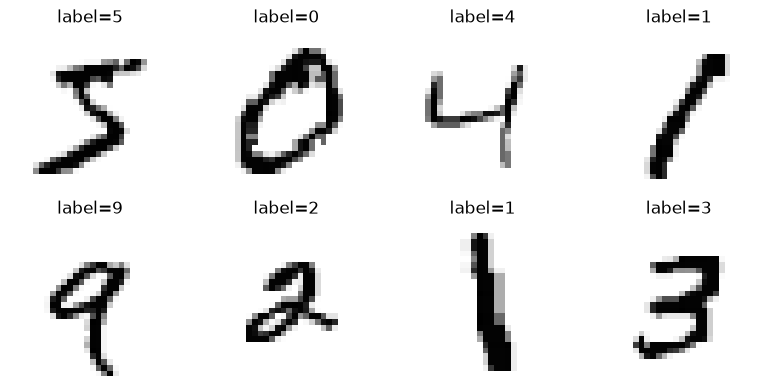

저장 위치 : C:\sk-encoa\dl-workspace\augmented_mnist
저장된 파일 수 : 8


In [6]:
from pathlib import Path
import matplotlib.pyplot  as plt
import numpy as np

save_dir = Path("./augmented_mnist")
save_dir.mkdir(parents=True, exist_ok=True)

row, col = 2, 4

transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=0.3,
        scale=(0.8, 1.2)
    )
])

mnist_train_raw = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

fig, axes = plt.subplots(row, col, figsize=(8, 4))
axes = np.asarray(axes).reshape(row, col)

for idx in range(row * col):
    image, label = mnist_train_raw[idx]

    augmented = transform(image)

    # PIL 이미지로 저장
    save_path = save_dir / f"aug_{idx+1:02d}_label_{label}.png"
    augmented.save(save_path)

    axes[idx // col, idx % col].imshow(augmented, cmap="Greys")
    axes[idx // col, idx % col].axis("off")
    axes[idx // col, idx % col].set_title(f"label={label}")

plt.tight_layout()
plt.show()

print(f"저장 위치 : {save_dir.resolve()}")
print("저장된 파일 수 :", len(list(save_dir.glob("*.png"))))
